# **Swiss Railway:** Complex Network Creation

In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

## **Data Analysis**

We have obtained two csv files from the website https://figshare.com/articles/dataset/Four_representations_of_the_Swiss_railway_network/29609615/2. One of them contains the data about the nodes and the other about the edges that connect those nodes.

In the following sections we will enter into detail about each one of those files.

### Node data

The node data of our network is in the file `nodelist.csv`. Each node represents one of the 1626 stations of the Swiss Railway network for all the rail companys in the country. Moreover, we have information available of the city where the station is located, the company that controls the station, the geographic location and about the average daily traffic of each node.

In [2]:
df_nodes = pd.read_csv("data/nodelist.csv", delimiter=';')

display(df_nodes)
display(df_nodes.dtypes)

,BPUIC,STATION_NAME,CANTON,MUNICIPALITY,COMPANY,LONGITUDE,LATITUDE,ELEVATION,AVG_DAILY_TRAFFIC,AVG_DAILY_TRAFFIC_WEEKDAYS,AVG_DAILY_TRAFFIC_WEEKENDS,TRAFFIC_VALID
0,8500010,Basel SBB,Basel-Stadt,Basel,Swiss Federal Railways SBB,7.589563,47.547412,276.75,98600.0,105900.0,81900.0,True
1,8500016,Basel St. Johann,Basel-Stadt,Basel,Swiss Federal Railways SBB,7.572529,47.570306,260.50,90.0,100.0,60.0,True
2,8500020,Muttenz,Basel-Landschaft,Muttenz,Swiss Federal Railways SBB,7.647894,47.533591,280.80,5700.0,7000.0,2800.0,True
3,8500021,Pratteln,Basel-Landschaft,Pratteln,Swiss Federal Railways SBB,7.690817,47.522669,289.60,8500.0,9900.0,5200.0,True
4,8500022,Frenkendorf-Füllinsdorf,Basel-Landschaft,Frenkendorf,Swiss Federal Railways SBB,7.719111,47.501470,310.96,3600.0,4100.0,2300.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...
1621,8593774,La Faverge,Vaud,Ormont-Dessus,Transports Publics du Chablais,7.147120,46.354930,1147.30,NaN,NaN,NaN,False
1622,8593775,Les Nicolets,Vaud,Ormont-Dessus,Transports Publics du Chablais,7.119540,46.354460,1096.60,NaN,NaN,NaN,False
1623,8593776,Plan Morier,Vaud,Ormont-Dessus,Transports Publics du Chablais,7.129200,46.353570,1108.60,NaN,NaN,NaN,False
1624,8594258,Langenthal Industrie Nord,Bern,Langenthal,Aare Seeland mobil (rvo),7.786471,47.228557,458.00,NaN,NaN,NaN,False


BPUIC                           int64
STATION_NAME                   object
CANTON                         object
MUNICIPALITY                   object
COMPANY                        object
LONGITUDE                     float64
LATITUDE                      float64
ELEVATION                     float64
AVG_DAILY_TRAFFIC             float64
AVG_DAILY_TRAFFIC_WEEKDAYS    float64
AVG_DAILY_TRAFFIC_WEEKENDS    float64
TRAFFIC_VALID                    bool
dtype: object

#### Visualizations

In [3]:
import plotly.express as px

px.histogram(df_nodes, x='COMPANY').update_xaxes(categoryorder='total descending')

In [4]:
fig = px.scatter_mapbox(
    df_nodes, 
    lat="LATITUDE", 
    lon="LONGITUDE", 
    color="COMPANY",
    hover_name="STATION_NAME",
    zoom=5,
    height=600
)

fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})

fig.show()

/tmp/ipykernel_5102/1038476195.py:1: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


### Edges data

The edges data of our network is in the file `edgelist_SoCha.csv`. Each row represents a directed edge between two stations connected by a direct service that requires no train changes. Moreover, we also have the average time duration of each interstation.

In [5]:
df_edges = pd.read_csv("data/edgelist_SoCha.csv", delimiter=';')

display(df_edges)
display(df_edges.dtypes)

,BPUIC1,BPUIC2,NUM_CONNECTIONS,AVG_DURATION
0,8503000,8500010,88,63.81
1,8503000,8500090,14,81.36
2,8500010,8500090,67,6.07
3,8500090,8500010,67,6.39
4,8500090,8503000,10,100.00
...,...,...,...,...
37940,8503464,8503466,37,6.00
37941,8503464,8503467,37,9.03
37942,8503465,8503466,37,2.00
37943,8503465,8503467,37,5.03


BPUIC1               int64
BPUIC2               int64
NUM_CONNECTIONS      int64
AVG_DURATION       float64
dtype: object

#### Visualizations

In [6]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=1, 
    cols=2, 
    subplot_titles=("NUM_CONNECTIONS distribution", "AVG_DURATION distribution")
)

fig.add_trace(
    go.Violin(
        y=df_edges['NUM_CONNECTIONS'],
        name='Connections',
        box_visible=True, # Muestra la caja (boxplot) dentro del violín
        meanline_visible=True, # Muestra la línea de la media
        fillcolor='lightblue',
        line_color='blue'
    ),
    row=1, col=1
)

fig.add_trace(
    go.Violin(
        y=df_edges['AVG_DURATION'],
        name='Average duration',
        box_visible=True,
        meanline_visible=True,
        fillcolor='lightgreen',
        line_color='green'
    ),
    row=1, col=2
)

fig.update_layout(
    showlegend=False,
    height=500
)

fig.update_yaxes(title_text="Number of connections", row=1, col=1)
fig.update_yaxes(title_text="Duration", row=1, col=2)

fig.show()

In [7]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- DATA PREPARATION ---
# Function to get the top 10 and obtain the station name of each one of them
def get_top_10_with_names(df_conn, column_name, df_n):
    top_10 = df_conn[column_name].value_counts().head(10).reset_index()
    top_10.columns = ['BPUIC', 'COUNT']
    
    top_10 = top_10.merge(df_n[['BPUIC', 'STATION_NAME']], on='BPUIC', how='left')
    
    return top_10

data_bpuic1 = get_top_10_with_names(df_edges, 'BPUIC1', df_nodes)
data_bpuic2 = get_top_10_with_names(df_edges, 'BPUIC2', df_nodes)


# --- VISUALIZATION CREATION ---
fig = make_subplots(
    rows=1, cols=2, 
    subplot_titles=("Top 10 stations with more outgoing tracks", "Top 10 stations with more incoming tracks")
)

fig.add_trace(
    go.Bar(
        x=data_bpuic1['STATION_NAME'], 
        y=data_bpuic1['COUNT'], 
        name='BPUIC1',
        marker_color='royalblue'
    ),
    row=1, col=1
)

fig.add_trace(
    go.Bar(
        x=data_bpuic2['STATION_NAME'], 
        y=data_bpuic2['COUNT'], 
        name='BPUIC2',
        marker_color='indianred'
    ),
    row=1, col=2
)

# Ajustamos el diseño
fig.update_layout(
    showlegend=False,
    height=500
)

# Rotamos ligeramente los nombres del eje X para que se lean bien si son muy largos
fig.update_xaxes(tickangle=-45)
fig.update_yaxes(title_text="count", row=1, col=1)
fig.update_yaxes(title_text="count", row=1, col=2)

fig.show()

### Are there connections between stations belonging to different companies? **YES**

In [8]:
import pandas as pd

# We add a column COMPANY1 that informs of the company of the origin station
df_edges_aux = df_edges.merge(
    df_nodes[['BPUIC', 'COMPANY']], 
    left_on='BPUIC1', 
    right_on='BPUIC', 
    how='left'
).rename(columns={'COMPANY': 'COMPANY1'}).drop(columns=['BPUIC'])

# We add COMPANY2 with the company of the destination station
df_edges_aux = df_edges_aux.merge(
    df_nodes[['BPUIC', 'COMPANY']], 
    left_on='BPUIC2', 
    right_on='BPUIC', 
    how='left'
).rename(columns={'COMPANY': 'COMPANY2'}).drop(columns=['BPUIC'])

mixed_connections = df_edges_aux[df_edges_aux['COMPANY1'] != df_edges_aux['COMPANY2']]

print(f"We have {len(mixed_connections)} connections between different companies.")
display(mixed_connections.head())

We have 4830 connections between different companies.


,BPUIC1,BPUIC2,NUM_CONNECTIONS,AVG_DURATION,COMPANY1,COMPANY2
1,8503000,8500090,14,81.36,Swiss Federal Railways SBB,Deutsche Eisenbahn-Infrastruktur in der Schweiz
2,8500010,8500090,67,6.07,Swiss Federal Railways SBB,Deutsche Eisenbahn-Infrastruktur in der Schweiz
3,8500090,8500010,67,6.39,Deutsche Eisenbahn-Infrastruktur in der Schweiz,Swiss Federal Railways SBB
4,8500090,8503000,10,100.00,Deutsche Eisenbahn-Infrastruktur in der Schweiz,Swiss Federal Railways SBB
6,8503424,8500090,17,73.18,Swiss Federal Railways SBB,Deutsche Eisenbahn-Infrastruktur in der Schweiz


## **Network creation**

## General information

In [9]:
# CREATE A REPRESENTATION
G=nx.from_pandas_edgelist(df_edges,source='BPUIC1',target='BPUIC2', edge_attr='AVG_DURATION', create_using=nx.DiGraph())
adj_matrix=nx.to_numpy_array(G)
# According to Networkx documentation: "For directed graphs, explicitly mention create_using=nx.DiGraph, 
#                                       and entry i,j of df corresponds to an edge from i to j." So the 
#                                       rows account for origins and the columns for destinations.

# INFO ABOUT THE NETWORK
n_nodes=G.number_of_nodes()
n_edges=G.number_of_edges()
print("-" * 10 + 'INFORMATION ABOUT THE NETWORK'+"-" * 10)
print(f"Number of nodes: {n_nodes}")
print(f"Number of edges: {n_edges}")
print(f"Matrix shape: {adj_matrix.shape}")

#SPARSITY
print('\n'+"-" * 10 + 'SPARSITY'+"-" * 10)
max_num_edges=n_nodes*(n_nodes-1)
proportion=n_edges/max_num_edges
print(f"Number of existing links / number total potential links: {proportion*100:.4f}%")
print(f"Sparsity: {(1-proportion)*100:.4f}%")



----------INFORMATION ABOUT THE NETWORK----------
Number of nodes: 1626
Number of edges: 37945
Matrix shape: (1626, 1626)

----------SPARSITY----------
Number of existing links / number total potential links: 1.4361%
Sparsity: 98.5639%


## Network visualization

We present a visualization of the whole network. Eventhough it is a directed network we represent the undirected network for two reasons: 
1. Since it's a very crowded map, the directions of the edges would be barely visible.
2. An undirected network still shows where there is more train movement (connections).

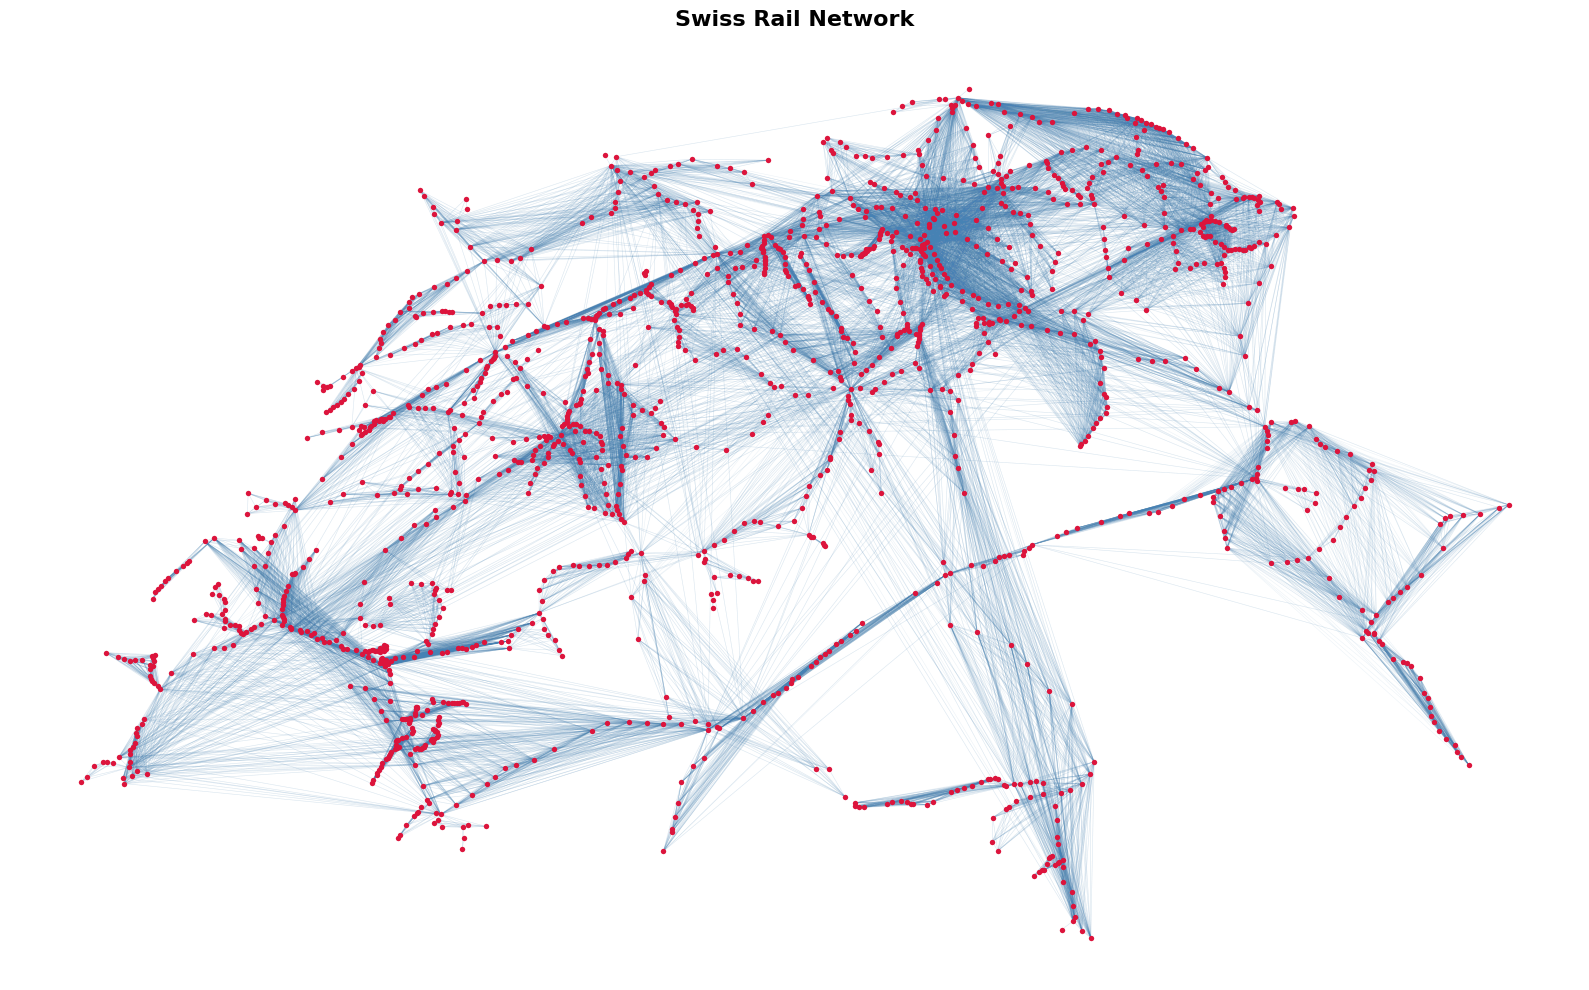

In [10]:
pos = {row['BPUIC']: (row['LONGITUDE'], row['LATITUDE']) for _, row in df_nodes.iterrows()}
fig, ax = plt.subplots(figsize=(16, 10), facecolor='white')

for u, v in G.edges():
    if u in pos and v in pos:
        x = [pos[u][0], pos[v][0]]
        y = [pos[u][1], pos[v][1]]
        ax.plot(x, y, color='steelblue', alpha=0.1, linewidth=0.4)

x_coords = [pos[n][0] for n in G.nodes() if n in pos]
y_coords = [pos[n][1] for n in G.nodes() if n in pos]
ax.scatter(x_coords, y_coords, s=15, c='crimson', zorder=5, linewidths=0)

ax.set_title("Swiss Rail Network", fontsize=16, fontweight='bold', pad=15)
ax.axis('off')
plt.tight_layout()
plt.show()

As we can see, the obtained representation of the network clearly resembles the shape of Switzerland. It also shows that the areas with more train connections (areas in darker blue) are around the biggest and most important cities of the country, as we could expect, such as Lausanne, Bern or Zürich. 

In the next plot we can see more clearly where each station (node) is located and that the network covers a wide range of the country.

In [11]:
fig = px.scatter_mapbox(
    df_nodes, 
    lat="LATITUDE", 
    lon="LONGITUDE",
    hover_name="STATION_NAME",
    zoom=7,
    height=600
)

fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})

fig.show()

/tmp/ipykernel_5102/1490763764.py:1: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


## In and Out degree vectors

In [12]:
#OUT DEGREE VECTOR
print('\n'+"-" * 10 + 'OUT DEGREE VECTOR'+"-" * 10)
print('TOP 10 ESTATIONS WITH MORE OUT-LINKS AND THEIR MUNICIPALITY')
print('Format: Station name, Municipality')
out_degree_vector=adj_matrix @ np.ones(n_nodes)
out_degree_vector_idx=list(zip(out_degree_vector, np.arange(0, n_nodes)))
out_ordered_deg_vect_idx = sorted(out_degree_vector_idx, key=lambda x: x[0], reverse=True)
out_ordered_deg_vect_idx = [(int(deg), int(idx)) for deg, idx in out_ordered_deg_vect_idx]
nodes=out_ordered_deg_vect_idx[:10]
node_list=list(G.nodes())
i=1
for deg,node in nodes:
    node_id=node_list[node]
    municipality = df_nodes.loc[df_nodes['BPUIC'] == node_id, 'MUNICIPALITY'].values[0]
    station= df_nodes.loc[df_nodes['BPUIC'] == node_id, 'STATION_NAME'].values[0]
    print(f'{i}. {station}, {municipality}')
    i+=1

    
#IN DEGREE VECTOR
print('\n'+"-" * 10 + 'IN DEGREE VECTOR'+"-" * 10)
print('TOP 10 ESTATIONS RECEIVING MORE IN-LINKS AND THEIR MUNICIPALITY')
print('Format: Station name, Municipality')
in_degree_vector=np.ones(n_nodes)@ adj_matrix
in_degree_vector_idx=list(zip(in_degree_vector, np.arange(0, n_nodes)))
in_ordered_deg_vect_idx = sorted(in_degree_vector_idx, key=lambda x: x[0], reverse=True)
in_ordered_deg_vect_idx = [(int(deg), int(idx)) for deg, idx in in_ordered_deg_vect_idx]
nodes=in_ordered_deg_vect_idx[:10]
node_list=list(G.nodes())
i=1
for deg,node in nodes:
    node_id=node_list[node]
    municipality = df_nodes.loc[df_nodes['BPUIC'] == node_id, 'MUNICIPALITY'].values[0]
    station= df_nodes.loc[df_nodes['BPUIC'] == node_id, 'STATION_NAME'].values[0]
    print(f'{i}. {station}, {municipality}')
    i+=1



----------OUT DEGREE VECTOR----------
TOP 10 ESTATIONS WITH MORE OUT-LINKS AND THEIR MUNICIPALITY
Format: Station name, Municipality
1. Zürich HB, Zürich
2. Bern, Bern
3. Olten, Olten
4. Luzern, Luzern
5. Winterthur, Winterthur
6. Zürich Oerlikon, Zürich
7. Rapperswil SG, Rapperswil-Jona
8. St. Gallen, St. Gallen
9. Zürich Stadelhofen, Zürich
10. Aarau, Aarau

----------IN DEGREE VECTOR----------
TOP 10 ESTATIONS RECEIVING MORE IN-LINKS AND THEIR MUNICIPALITY
Format: Station name, Municipality
1. Zürich HB, Zürich
2. Bern, Bern
3. Olten, Olten
4. Winterthur, Winterthur
5. Zürich Oerlikon, Zürich
6. Luzern, Luzern
7. Rapperswil SG, Rapperswil-Jona
8. St. Gallen, St. Gallen
9. Zürich Stadelhofen, Zürich
10. Zürich Hardbrücke, Zürich


As we can see, these two lists coincide with the stations appearing in the graphs abouve with the Top 10 stations with more outgoing/ingoing tracks. They obviously had to coincide. It is a good indicator of having built the correct adjacency matrix and of the good computation of the out and in degree vectors. 

## Shortest paths and connectedness

In [13]:
# SHORTEST PATHS (BASED ON NUMBER OF TRAIN CHANGES)
# When trying to do 
#           avg_shortest_path = nx.average_shortest_path_length(G)
#           print(f"Average shortest path length: {avg_shortest_path:.4f}") 

This code produces and error because the network is not strongly connected and therefore the average in the network cannot be computed. We study connectedness now and we will go deeper in each strongly connected component later in this notebook.

In [14]:
# CONNECTEDNESS
# Since we are working with a directed network we cannot use the multiplicity 
# of the eigenvalue 0 of the Laplacian matrix as a topological descriptor of network.
# We can use built in methods of the networkx library. 
if nx.is_strongly_connected(G):
    print ('The Swiss rail network is strongly connected!')
else: 
    n_conn_comp = nx.number_strongly_connected_components(G)
    print(f'The Swiss rail network is NOT strongly connected!, there are {n_conn_comp} strongly connected components.')
    if nx.is_weakly_connected(G):
        print('But the network is weakly connected')
    else:
        n_wconn_comp = nx.number_weakly_connected_components(G)
        print(f'The network is not weakly connected either, there are {n_wconn_comp} weakly connected components.\n'
        f'If we want to compute any shortest path in the network, we must ensure both origin and destiantion nodes are the same connected component.')




The Swiss rail network is NOT strongly connected!, there are 4 strongly connected components.
The network is not weakly connected either, there are 4 weakly connected components.
If we want to compute any shortest path in the network, we must ensure both origin and destiantion nodes are the same connected component.


## Centrality study

We now study the centrality of the nodes, to get an idea of which of them could be considered the most important or key nodes in the network.

In [15]:
import networkx as nx
import pandas as pd

# NetwrokX centrality metrics
deg_cent = nx.degree_centrality(G)
in_deg_cent = nx.in_degree_centrality(G)
out_deg_cent = nx.out_degree_centrality(G)
clo_cent = nx.closeness_centrality(G, distance='AVG_DURATION')
#clo_cent = nx.closeness_centrality(G)
bet_cent = nx.betweenness_centrality(G, weight='AVG_DURATION')
#bet_cent = nx.betweenness_centrality(G)

df_centrality = pd.DataFrame({
    'Degree': deg_cent,
    'In-Degree': in_deg_cent,
    'Out-Degree': out_deg_cent,
    'Closeness': clo_cent,
    'Betweenness': bet_cent
}).reset_index().rename(columns={'index': 'BPUIC'})

# Merge with df_nodes to get the station names
df_report = df_centrality.merge(df_nodes[['BPUIC', 'STATION_NAME']], on='BPUIC', how='left')

# Reordering of the columns
cols = ['BPUIC', 'STATION_NAME', 'Degree', 'In-Degree', 'Out-Degree', 'Closeness', 'Betweenness']
df_report = df_report[cols]


print("--- STATION CENTRALITY REPORT ---")

print("\nTOP 3: Most connected stations (Degree Centrality)")
print("Measures the proportion of stations to which the current station is directly connected.")
display(df_report.sort_values('Degree', ascending=False)[['STATION_NAME', 'Degree']].head(3))

print("\nBottom 3: Least connected stations (Degree Centrality)")
display(df_report.sort_values('Degree', ascending=True)[['STATION_NAME', 'Degree']].head(3))

print("\n\nTOP 3: Most central hubs (Closeness Centrality)")
print("Measures how fast you can reach all other stations from this one (shortest paths in terms of time).")
display(df_report.sort_values('Closeness', ascending=False)[['STATION_NAME', 'Closeness']].head(3))

print("\nBottom 3: Most isolated / Slowest (Closeness Centrality)")
display(df_report.sort_values('Closeness', ascending=True)[['STATION_NAME', 'Closeness']].head(3))

print("\n\nTOP 3: Bridge nodes / Bottlenecks (Betweenness Centrality)")
print("Measures how often this station acts as a mandatory pass-through in the shortest routes (in terms of time) between two other stations.")
display(df_report.sort_values('Betweenness', ascending=False)[['STATION_NAME', 'Betweenness']].head(3))

print("\nBottom 3: Dead-ends / Zero impact on routing (Betweenness Centrality)")
display(df_report.sort_values('Betweenness', ascending=True)[['STATION_NAME', 'Betweenness']].head(3))

--- STATION CENTRALITY REPORT ---

TOP 3: Most connected stations (Degree Centrality)
Measures the proportion of stations to which the current station is directly connected.


,STATION_NAME,Degree
0,Zürich HB,0.347692
587,Bern,0.230154
680,Olten,0.211077



Bottom 3: Least connected stations (Degree Centrality)


,STATION_NAME,Degree
1209,Basel St. Johann,0.001231
1109,Stabio,0.001231
953,Herblingen,0.001231




TOP 3: Most central hubs (Closeness Centrality)
Measures how fast you can reach all other stations from this one (shortest paths in terms of time).


...

,STATION_NAME,Closeness
180,Mürren BLM,0.000153
182,Grütschalp,0.000164
181,Winteregg,0.000274




TOP 3: Bridge nodes / Bottlenecks (Betweenness Centrality)
Measures how often this station acts as a mandatory pass-through in the shortest routes (in terms of time) between two other stations.


,STATION_NAME,Betweenness
0,Zürich HB,0.375416
587,Bern,0.259308
809,Zürich Stadelhofen,0.196092



Bottom 3: Dead-ends / Zero impact on routing (Betweenness Centrality)


,STATION_NAME,Betweenness
1620,Trasadingen,0.0
1296,Sumiswald-Grünen,0.0
1209,Basel St. Johann,0.0


Interpretation of results:
* DEGREE CENTRALITY:
Zürich HB ranks first with a score of 0.35, meaning it is directly connected to 35% of all stations in the network. Bern and Olten follow closely, both being also major junctions that serve as entry points to large portions of the network. At the bottom, Herblingen, Basel St. Johann and Stabio all share the minimum score of 0.001231, meaning they each have just one or two direct connections 

* CLOSENESS CENTRALITY: 
Olten ranks first here, meaning it can reach all other stations faster in terms of time than any other node in the network in terms of travel time. Bern Wankdorf and Bern are second and third with highest closeness centrality, probably due to the fact that the Bern area is in the middle of the country. At the bottom, Mürren BLM, Grütschalp and Winteregg score near zero. We will see later that these stations are quite disconnected from the rest of the network.

* BETWEENNESS CENTRALITY: 
Zürich HB scores 0.38, meaning 38% of all shortest paths in terms of time in the entire network pass through it. Bern follows with 0.26 and Zürich Stadelhofen with a 0.20. Zürich Stadelhofen is also a station in Zürich, and even though it ranks lower than Zürich HB, it is also a key station. This also shows the importance of stations in the city of Zürich.

Overall, the Zürich HB station appears to be one of the most central and key nodes in the network, followed by Bern and Olten.

In [17]:
#LETS COMPUTE SOME OTHER CENTRALITIES: EIGEVECTOR CENTRALITY AND KATZ CENTRALITY
# Get largest eigenvalue for alpha
import numpy as np
eigenvalues = nx.adjacency_spectrum(G)
largest_eigenvalue = max(abs(eigenvalues))
print(f"Largest eigenvalue: {largest_eigenvalue:.4f}")
alpha = 0.8 / largest_eigenvalue
print(f"Alpha: {alpha:.4f}")

# Eigenvector centrality
try:
    eig_cent = nx.eigenvector_centrality(G, max_iter=1000)
except nx.PowerIterationFailedConvergence:
    print("Eigenvector centrality did not converge, try increasing max_iter")
    eig_cent = {node: 0 for node in G.nodes()}

# Katz centrality
try:
    katz_cent = nx.katz_centrality(G, alpha=alpha)
except nx.PowerIterationFailedConvergence:
    print("Katz centrality did not converge")
    katz_cent = {node: 0 for node in G.nodes()}

# Rebuild dataframe with all centralities
df_centrality = pd.DataFrame({
    'Degree': deg_cent,
    'In-Degree': in_deg_cent,
    'Out-Degree': out_deg_cent,
    'Closeness': clo_cent,
    'Betweenness': bet_cent,
    'Eigenvector': eig_cent,
    'Katz': katz_cent
}).reset_index().rename(columns={'index': 'BPUIC'})

# Merge with df_nodes
df_report = df_centrality.merge(df_nodes[['BPUIC', 'STATION_NAME']], on='BPUIC', how='left')

# Reorder columns
cols = ['BPUIC', 'STATION_NAME', 'Degree', 'In-Degree', 'Out-Degree', 'Closeness', 'Betweenness', 'Eigenvector', 'Katz']
df_report = df_report[cols]

print("\n\nTOP 3: Most influential stations (Eigenvector Centrality)")
print("Measures influence based on the quality of connections — being connected to well-connected stations matters more.")
display(df_report.sort_values('Eigenvector', ascending=False)[['STATION_NAME', 'Eigenvector']].head(3))

print("\nBottom 3: Least influential (Eigenvector Centrality)")
display(df_report.sort_values('Eigenvector', ascending=True)[['STATION_NAME', 'Eigenvector']].head(3))

print("\n\nTOP 3: Most influential stations (Katz Centrality)")
print("Similar to Eigenvector but also counts longer paths with a decay factor — more robust for directed graphs.")
display(df_report.sort_values('Katz', ascending=False)[['STATION_NAME', 'Katz']].head(3))

print("\nBottom 3: Least influential (Katz Centrality)")
display(df_report.sort_values('Katz', ascending=True)[['STATION_NAME', 'Katz']].head(3))

Largest eigenvalue: 50.2625
Alpha: 0.0159


TOP 3: Most influential stations (Eigenvector Centrality)
Measures influence based on the quality of connections — being connected to well-connected stations matters more.


,STATION_NAME,Eigenvector
0,Zürich HB,0.245729
706,Winterthur,0.178241
766,Zürich Oerlikon,0.171631



Bottom 3: Least influential (Eigenvector Centrality)


,STATION_NAME,Eigenvector
181,Winteregg,2.588606e-35
182,Grütschalp,2.588606e-35
180,Mürren BLM,2.588606e-35




TOP 3: Most influential stations (Katz Centrality)
Similar to Eigenvector but also counts longer paths with a decay factor — more robust for directed graphs.


,STATION_NAME,Katz
0,Zürich HB,0.187097
706,Winterthur,0.129901
766,Zürich Oerlikon,0.122402



Bottom 3: Least influential (Katz Centrality)


,STATION_NAME,Katz
181,Winteregg,0.009111
182,Grütschalp,0.009111
180,Mürren BLM,0.009111


* EIGENVECTOR CENTRALITY: Zürich HB again ranks first with and eigenvector centrality of 0.246, followed by Winterthur and Zürich Oerlikon. The top 3 stations are all in the Zürich metropolitan area. This means that while Bern and Olten are well connected, their neighbors are less influential than Zürich's neighbors. Zürich HB is not only connected to many stations, but those stations are themselves highly connected, making the whole area very influential. At the bottom, Mürren BLM, Winteregg and Grütschalp appear again, almost with a score of 0. This also shows how isolated these stations are from the others.

* KATZ CENTRALITY: Same interpretation as in eigenvector centrality.

## Clustering

To study clustering we need to be careful, since the network is directed. Some of the built in methods for clustering analysis are not supported for directed graphs, other are. For instance: 

SUPPORTED:

* Clustering(): https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.cluster.clustering.html

NOT SUPPORTED (check bottom of the link):

* Average_clustering(): https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.cluster.average_clustering.html#networkx.algorithms.cluster.average_clustering 

* Transitivity(): https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.cluster.transitivity.html#networkx.algorithms.cluster.transitivity 

We will compute the clustering coefficientes for our directed graph and teh Average_clustering and Transitivity for hte undirected version of our graph.

In [18]:
# Directed
clustering = nx.clustering(G)

# Undirected
G_undirected = G.to_undirected()
transitivity = nx.transitivity(G_undirected)
average_clustering = nx.average_clustering(G_undirected)

print(f'TRANSITIVITY (computed on undirected graph): {transitivity*100:.4f}%')
print(f'AVERAGE CLUSTERING (computed on undirected graph): {average_clustering}')
clustering_df = pd.DataFrame({
    'BPUIC': list(clustering.keys()),
    'Clustering': list(clustering.values())
})
clustering_df = clustering_df.merge(df_nodes[['BPUIC', 'STATION_NAME']], on='BPUIC', how='left')
n_clustering_one = (clustering_df['Clustering'] == 1).sum()
print(f"Number of stations with CLUSTERING COEFFICIENT = 1: {n_clustering_one}")
print("NOTE: Transitivity and average clustering are computed on the undirected version as NetworkX does not support directed graphs for these metrics.")

TRANSITIVITY (computed on undirected graph): 54.2148%
AVERAGE CLUSTERING (computed on undirected graph): 0.8859416948256237
Number of stations with CLUSTERING COEFFICIENT = 1: 944
NOTE: Transitivity and average clustering are computed on the undirected version as NetworkX does not support directed graphs for these metrics.


We observe that 944/1626 (≈58%) of nodes have clustering coefficient equal to 1 in the directed version of the network. This indicates that many nodes are in highly interconnected local neighborhoods.

## Strongly connected components

We analyze the strongly connected components of the network, and we realise that there is one big strongly connected component with almost $98%$ of the nodes of the network and another 3 smaller strongly connected components.

In [26]:
# Taking a look at the strongly connected components. 
# Number of nodes in each component
strongly_connected_components = list(nx.strongly_connected_components(G))
# Sort components by size
sorted_components = sorted(strongly_connected_components, key=len)
print('Number of nodes in each strongly connected component')
for i, component in enumerate(sorted_components):
    print(f"Component {i+1} has {len(component)} nodes")

# Names of the stations and their municipalities in the 3 components with less nodes
# We don't expect names of big cities here. Let's check.
smallest_3 = sorted_components[:3]
print("\n\nNames of the stations and their municipalities in the 3 components with less nodes")
for i, component in enumerate(smallest_3):
    print(f"\nComponent {i+1} ({len(component)} nodes):")
    for node in component:
        station = df_nodes.loc[df_nodes['BPUIC'] == node, 'STATION_NAME'].values[0]
        municipality = df_nodes.loc[df_nodes['BPUIC'] == node, 'MUNICIPALITY'].values[0]
        print(f"  - {station}, {municipality}")
    # Filter df_nodes to only nodes in that component
    df_component = df_nodes[df_nodes['BPUIC'].isin(component)]

    fig = px.scatter_mapbox(
        df_component,
        lat="LATITUDE",
        lon="LONGITUDE",
        hover_name="STATION_NAME",
        center={"lat": df_component["LATITUDE"].mean(), 
            "lon": df_component["LONGITUDE"].mean()},
        height=400)

    fig.update_layout(mapbox_style="open-street-map")
    fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
    fig.show()

Number of nodes in each strongly connected component
Component 1 has 3 nodes
Component 2 has 12 nodes
Component 3 has 19 nodes
Component 4 has 1592 nodes


Names of the stations and their municipalities in the 3 components with less nodes

Component 1 (3 nodes):
  - Winteregg, Lauterbrunnen
  - Grütschalp, Lauterbrunnen
  - Mürren BLM, Lauterbrunnen


/tmp/ipykernel_5102/369748065.py:23: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(



Component 2 (12 nodes):
  - Colombier NE Littorail, Milvignes
  - Areuse Littorail, Boudry
  - Neuchâtel Place Pury Littorail, Neuchâtel
  - Neuchâtel Evole, Neuchâtel
  - Neuchâtel Champ-Bougin, Neuchâtel
  - Neuchâtel Serrières Ruau, Neuchâtel
  - Colombier NE Allées Littorail, Milvignes
  - Colombier NE Les Chézards, Milvignes
  - Boudry Tuilière, Boudry
  - Neuchâtel Port-de-Serrières, Neuchâtel
  - Auvernier Littorail, Milvignes
  - Boudry Littorail, Boudry


/tmp/ipykernel_5102/369748065.py:23: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(



Component 3 (19 nodes):
  - Lausanne-Chauderon, Lausanne
  - Union-Prilly, Prilly
  - Prilly-Chasseur, Prilly
  - Cery-Fleur-de-Lys, Prilly
  - Jouxtens-Mézery, Jouxtens-Mézery
  - Romanel-sur-Lausanne, Romanel-sur-Lausanne
  - Vernand-Camarès, Lausanne
  - Cheseaux, Cheseaux-sur-Lausanne
  - Bel-Air LEB, Lausanne
  - Etagnières, Etagnières
  - Assens, Assens
  - Echallens, Echallens
  - Sur Roche, Echallens
  - Sugnens, Montilliez
  - Fey, Fey
  - Bercher, Bercher
  - Grésaley, Echallens
  - Lausanne-Flon, Lausanne
  - Les Ripes, Etagnières


/tmp/ipykernel_5102/369748065.py:23: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


As expected, most important stations of the main cities of the country are not present in the small strongly connected components. The fact that these regions are separated can be for various regions: 
- Difficult areas for building train tracks. This could be the case of Component 1, as those stations are in a mountainous area and Component 2, also in a montainous area and close to a lake.
- Low population areas. Having less population may imply less train connections. This could be the case of Component 1.
- Isolated companies with local objectives. This happens in all these last 3 components that we have shown. These components were created for a local (or inter-city) porpouse and sometimes can not be connected with other company rails due to the type of train used or, simply, because this part of the track was not created with the aim connecting it with a bigger network.

Finally, we compute the shortest path by connection and travelling time in each component.


In [27]:
# Since we couldn't study the average shortest path in the whole network because it is not strongly connected, 
# we do it in the strongly connected components. 
# We compute the SHORTEST PATH by connections and travelling time
print(f'Avg shortest path by connection')
for i, component in enumerate(sorted_components):
    subgraph = G.subgraph(component)
    if len(component) > 1:
        avg_sp = nx.average_shortest_path_length(subgraph)
        print(f"Component {i+1} ({len(component)} nodes): avg shortest path = {avg_sp:.4f}")
    else:
        print(f"Component {i+1} ({len(component)} nodes): single node, no path")

print(f'\nAvg shortest path by duration')
for i, component in enumerate(sorted_components):
    subgraph = G.subgraph(component)
    if len(component) > 1:
        avg_sp = nx.average_shortest_path_length(subgraph, weight='AVG_DURATION')
        print(f"Component {i+1} ({len(component)} nodes): avg shortest path = {avg_sp:.4f}")
    else:
        print(f"Component {i+1} ({len(component)} nodes): single node, no path")

Avg shortest path by connection
Component 1 (3 nodes): avg shortest path = 1.0000
Component 2 (12 nodes): avg shortest path = 1.0000
Component 3 (19 nodes): avg shortest path = 1.0000
Component 4 (1592 nodes): avg shortest path = 3.3360

Avg shortest path by duration
Component 1 (3 nodes): avg shortest path = 6.6733
Component 2 (12 nodes): avg shortest path = 3.9777
Component 3 (19 nodes): avg shortest path = 11.5872
Component 4 (1592 nodes): avg shortest path = 141.7143


Since the last 3 connected components have very few nodes compared to the biggest one, we could see the average shortest path in the first big component as an indicator of the average shortest path in the whole network, both when talking about shortest path regarding connection and travel duration. For instance, in Component 1, we would need an average of 3.33 train connections to go from any node of the component to another one and about 141 minutes. Of course, the bigger the component is the more train connections we need to make and the longer the average journey will be.